<a href="https://colab.research.google.com/github/NadiiaIvashchuk/DTA_2026/blob/main/ML/ML_Pipeplines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

# ---------- Датасет: ВІДТІК (класифікація) ----------
m = 1500
tenure  = np.random.randint(1, 72, m)
monthly = np.random.normal(70, 25, m).clip(15, 150)
support = np.random.poisson(1.5, m)
age     = np.random.randint(18, 75, m)
contract = np.random.choice(["місячний", "річний", "дворічний"], m, p=[.5, .3, .2])
contract_risk = pd.Series({"місячний": .8, "річний": -.3, "дворічний": -.8})

risk = (-0.05*tenure + 0.02*monthly + 0.45*support - 0.01*age
        + contract_risk[contract].values + np.random.normal(0, .7, m))
prob = 1/(1+np.exp(-(risk-0.5)))
churn = (np.random.rand(m) < prob).astype(int)

cust = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1), "support": support,
    "age": age, "contract": contract, "churn": churn,
})

print("Частка відтоку:", f"{cust['churn'].mean():.1%}")
cust

Частка відтоку: 43.2%


,tenure,monthly,support,age,contract,churn
0,52,82.1,2,42,дворічний,1
1,15,59.5,5,69,дворічний,1
2,61,98.3,3,71,річний,0
3,21,63.1,0,41,місячний,1
4,24,104.6,5,74,місячний,1
...,...,...,...,...,...,...
1495,28,104.6,5,42,річний,1
1496,35,68.9,2,73,місячний,0
1497,61,118.3,0,48,річний,0
1498,54,67.5,3,54,місячний,0


# Масштабування

In [2]:
#Сатандартизація - пропорційне стискання даних в -1 до 1, де 0 - це mean
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sample = cust[['age', 'monthly', 'tenure']].copy() # ознаки з малими значеннями (0≈5), або категорії, яkі можна замінити на [0,1,2]
print("До масштабування (різні діапазони)")
sample.describe().loc[['mean', 'min', 'max']].round(1) #обираємо важливі для нас показники

До масштабування (різні діапазони)


,age,monthly,tenure
mean,45.6,70.9,35.4
min,18.0,15.0,1.0
max,74.0,150.0,71.0


In [3]:
scaler = StandardScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(sample), # навчити і змінити
    columns=sample.columns
)

print("Після застосування методу StandardScaler (середнє≈0, розкид≈1, усі в одній рамці)")
scaled.describe().loc[['mean', 'min', 'max']].round(2)

Після застосування методу StandardScaler (середнє≈0, розкид≈1, усі в одній рамці)


,age,monthly,tenure
mean,0.00,0.00,0.00
min,-1.68,-2.18,-1.68
max,1.73,3.08,1.73


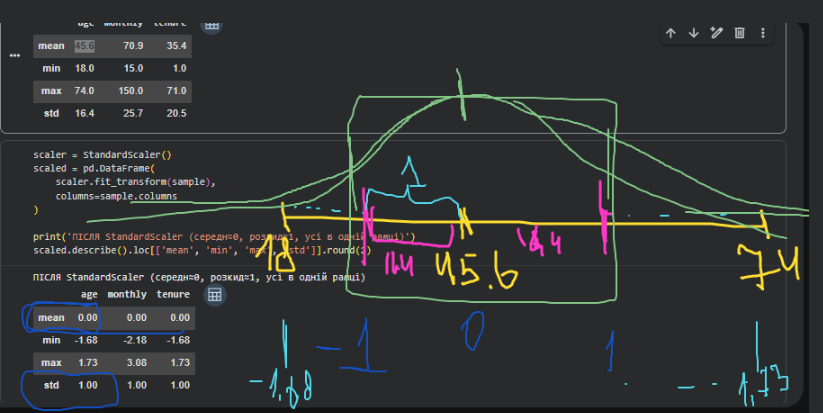

In [4]:
#Нормалізація - стискаємо всі значення від 0 до 1, mean - розраховуємо наново для нових значень
scaler_min_max = MinMaxScaler()
scaled_min_max = pd.DataFrame(
    scaler_min_max.fit_transform(sample), # навчити і змінити
    columns=sample.columns
)

print("Після застосування методу MinMaxScaler (min=0, max=1, усі в одній рамці)")
scaled_min_max.describe().loc[['mean', 'min', 'max']].round(2)

Після застосування методу MinMaxScaler (min=0, max=1, усі в одній рамці)


,age,monthly,tenure
mean,0.49,0.41,0.49
min,0.00,0.00,0.00
max,1.00,1.00,1.00


- `model.fit(X_train)` - навчання на тренувальних даних
- `model.transform()` - застосовуємо параметри (зараз це масштабування) до обраного набору даних:
  - `model.transform(X_train)`, `model.transform(X_test)`- важливо застосовувати для обох наборів даних
- `vodel.fit_transform(df)` - застосовуємо параметри та навчаємо модель на обраних даних одночасно (без поділу)

# Pipelines

In [5]:
from sklearn import preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score

X = cust[['tenure', 'monthly', 'support', 'age', 'contract']]
y = cust['churn']

num_cols = ['tenure', 'monthly', 'support', 'age']
cat_cols = ['contract']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipe = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

pipe.fit(X_train, y_train)
print('Accuracy на тесті:', round(pipe.score(X_test, y_test), 3))

Accuracy на тесті: 0.74


In [7]:
cv = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
print(f'CV accuracy: {np.round(cv, 3)} | середнє: {cv.mean():.3f} ± {cv.std():.3f}')

CV accuracy: [0.767 0.747 0.683 0.74  0.747] | середнє: 0.737 ± 0.028


In [8]:
new_client = pd.DataFrame([{
    'tenure': 40,
    'monthly': 80.5,
    'support': 5,
    'age': 30,
    'contract': 'дворічний'
}])
display(new_client)
print('\nКлієнт -', 'ПІДЕ' if pipe.predict(new_client) else 'залишиться')

,tenure,monthly,support,age,contract
0,40,80.5,5,30,дворічний



Клієнт - ПІДЕ


In [9]:
new_client2 = pd.DataFrame([{
    'tenure': 40,
    'monthly': 50,
    'support': 5,
    'age': 30,
    'contract': 'трирічний'
}])

display(new_client2)

print('\nКлієнт -', 'ПІДЕ' if pipe.predict(new_client2) else 'залишиться')

,tenure,monthly,support,age,contract
0,40,50,5,30,трирічний



Клієнт - ПІДЕ


In [10]:
new_client3 = pd.DataFrame([{
    'tenure': 40,
    'monthly': 50,
    'support': 5,
    'age': 30,
    'contract': 'дворічний'
}])

display(new_client3)

print('\nКлієнт -', 'ПІДЕ' if pipe.predict(new_client3) else 'залишиться')

,tenure,monthly,support,age,contract
0,40,50,5,30,дворічний



Клієнт - залишиться


# Логістична регресія - LogistikRegression

- pipe - LogistikRegression
- поріг (для р-значення) завжди значення 0.5 (середнє між 0 і 1)

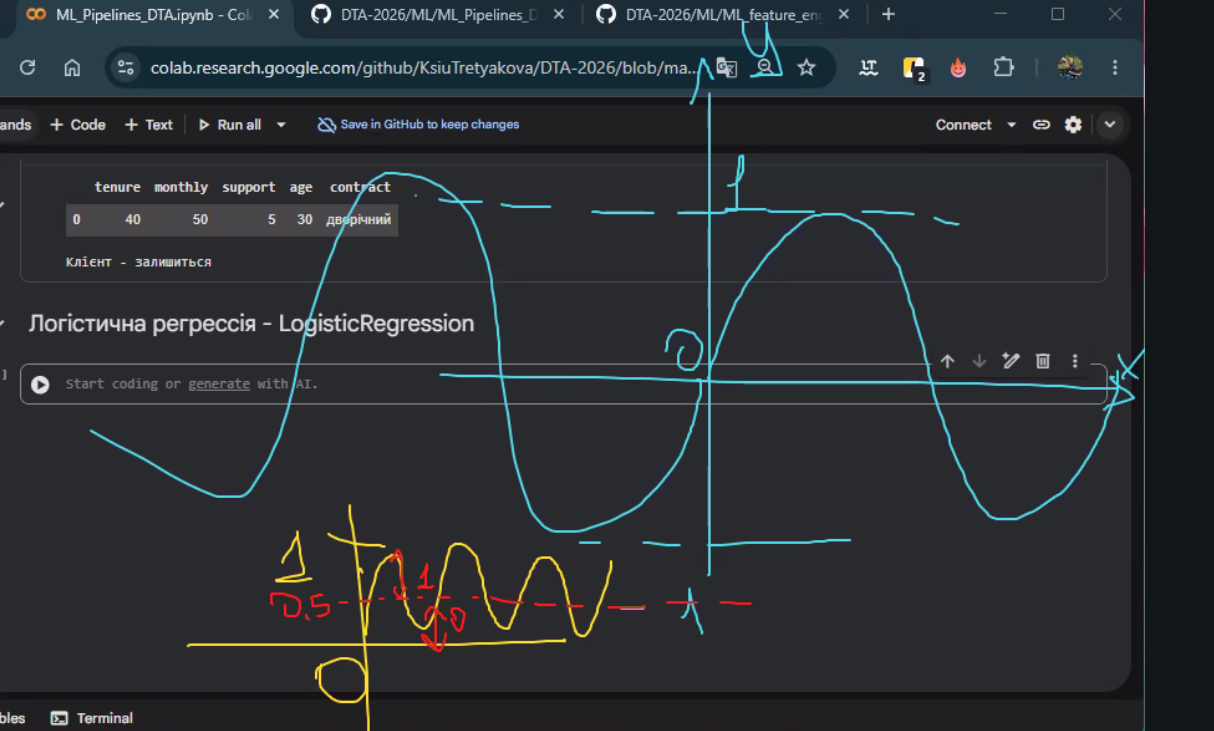

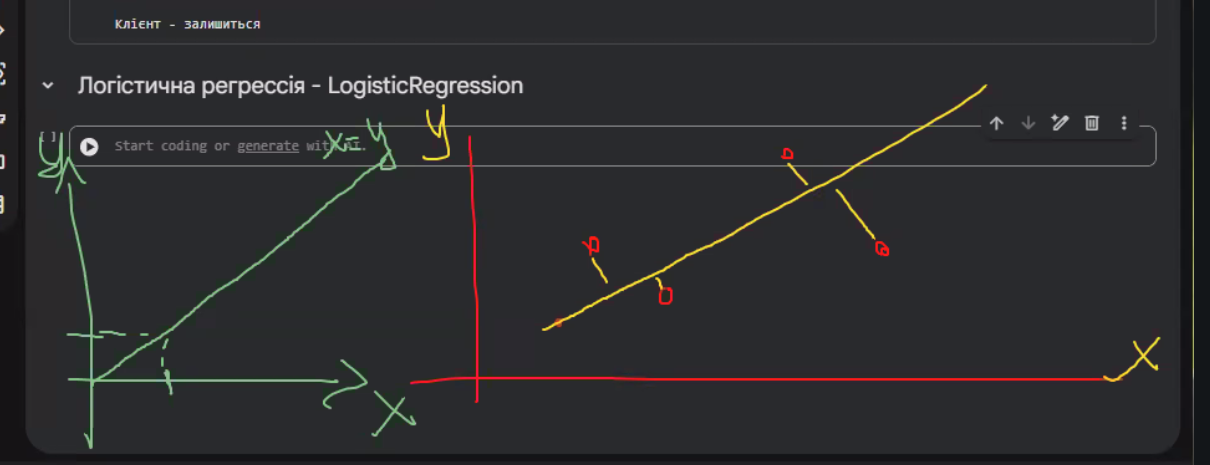

1 - linearregression, 2 - LogisticsRegression

In [16]:
from sklearn.metrics import classification_report

proba = pipe.predict_proba(X_test)[:,1]
pred = pipe.predict(X_test)

demo = X_test.head().copy()
#demo['proba(піде)'] = proba[:5].round(2)
#demo['рішення (поріг 0.5)'] = pred[:5]
demo['рішення (поріг 0.5)'] = np.where(pred[:5], 'ПІДЕ', 'ЗАЛИШИТЬСЯ')

demo

,tenure,monthly,support,age,contract,proba(піде),рішення (поріг 0.5)
599,62,52.6,1,50,річний,0.06,ЗАЛИШИТЬСЯ
1236,61,42.9,3,60,місячний,0.27,ЗАЛИШИТЬСЯ
1452,49,77.1,0,18,місячний,0.27,ЗАЛИШИТЬСЯ
334,5,80.5,2,26,дворічний,0.66,ПІДЕ
123,42,16.1,3,52,місячний,0.35,ЗАЛИШИТЬСЯ


In [22]:
feat_names = pipe.named_steps['prep'].get_feature_names_out()
coefs = pipe.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({
    'features': feat_names,
    'coef': coefs
}).sort_values('coef', key=abs, ascending=False)

print("Вплив на ризик відтоку(+ підвищує ризик, - знижує)")
coef_df

Вплив на ризик відтоку(+ підвищує ризик, - знижує)


,features,coef
0,num__tenure,-1.009760
5,cat__contract_місячний,0.829437
4,cat__contract_дворічний,-0.635490
2,num__support,0.554154
1,num__monthly,0.525213
6,cat__contract_річний,-0.189502
3,num__age,-0.019732


Варіант, коли ми застосовуємо більш "депресивний підхід до прогнозування при навчанні моделі (через ознаки)

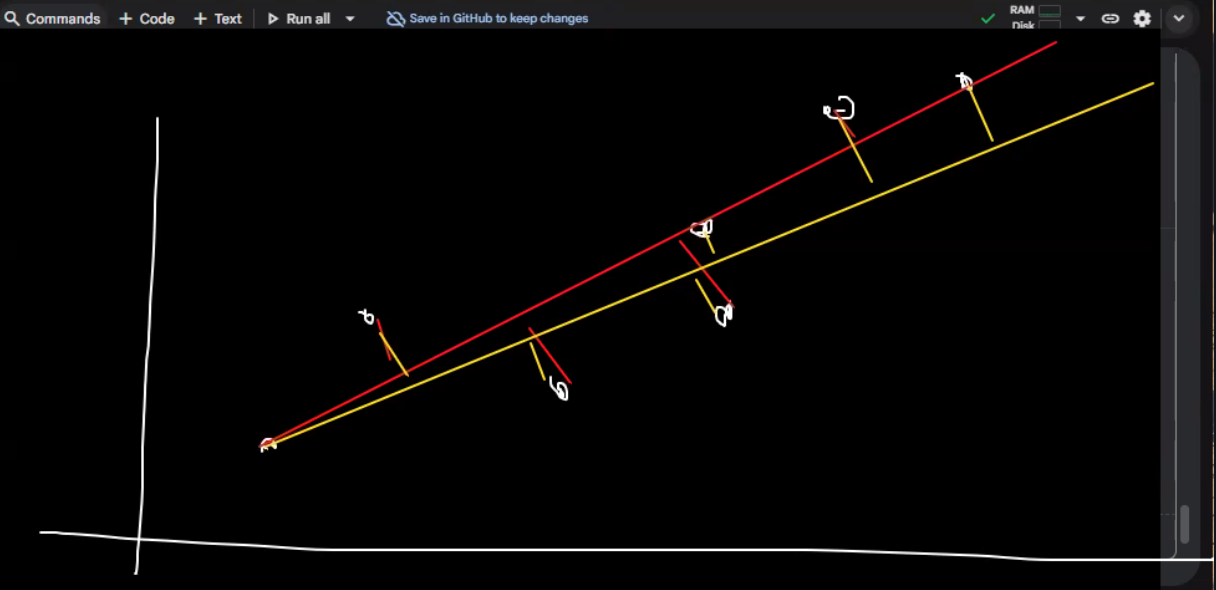